# SVM – Linear vs Kernel Trick

**Goal:** Understand when linear SVM works, when it fails, and how the kernel trick (RBF) overcomes non‑linearity.

## What You Will Do

1. **Linear SVM on linearly separable data** – see perfect separation.
2. **Linear SVM on nonlinearly separable data (moons)** – observe failure.
3. **RBF Kernel SVM on the same non‑linear data** – recover performance.
4. Tune `C` and `gamma` to see their effect.
5. Visualise decision boundaries and answer questions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# For decision boundary plotting
def plot_decision_boundary(clf, X, y, title, ax=None):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

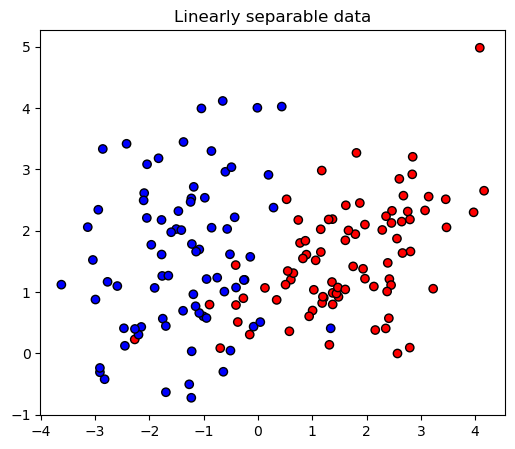

In [2]:
# Generate 2D linearly separable data
X_lin, y_lin = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                   n_clusters_per_class=1, n_classes=2,
                                   class_sep=1.5, random_state=42)
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(X_train_lin[:,0], X_train_lin[:,1], c=y_train_lin, cmap='bwr', edgecolors='k')
plt.title('Linearly separable data')
plt.show()

Linear SVM accuracy on linearly separable data: 0.9000


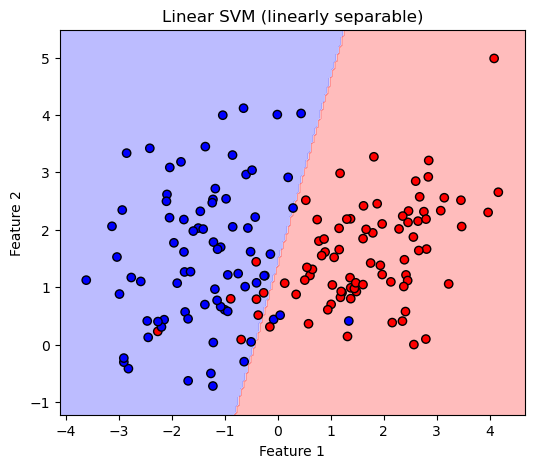

In [3]:
# TODO: Create a linear SVM classifier with C=1.0
# clf_lin = SVC(kernel='linear', C=1.0)
clf_lin = SVC(kernel='linear', C=1.0)
clf_lin.fit(X_train_lin, y_train_lin)

# Evaluate
y_pred_lin = clf_lin.predict(X_test_lin)
acc_lin = accuracy_score(y_test_lin, y_pred_lin)
print(f"Linear SVM accuracy on linearly separable data: {acc_lin:.4f}")

# Plot decision boundary
fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(clf_lin, X_train_lin, y_train_lin, 'Linear SVM (linearly separable)', ax)
plt.show()

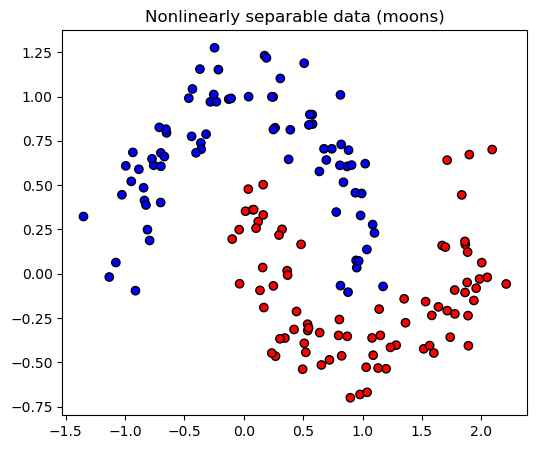

In [7]:
# Generate nonlinearly separable data (two interlocking moons)
X_moon, y_moon = make_moons(n_samples=200, noise=0.15, random_state=42)
X_train_moon, X_test_moon, y_train_moon, y_test_moon = train_test_split(
    X_moon, y_moon, test_size=0.2, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(X_train_moon[:,0], X_train_moon[:,1], c=y_train_moon, cmap='bwr', edgecolors='k')
plt.title('Nonlinearly separable data (moons)')
plt.show()

Linear SVM accuracy on moons: 0.8500


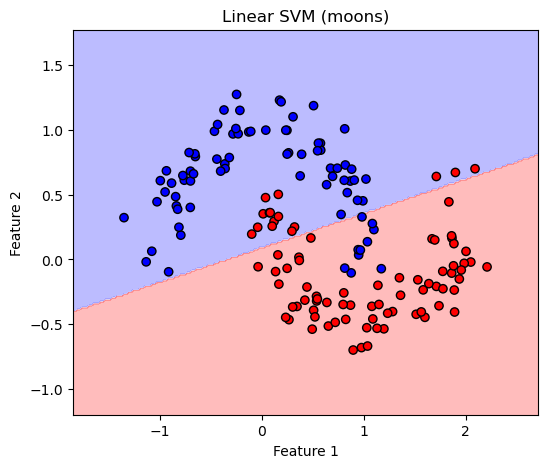

In [9]:
# TODO: Train a linear SVM on the moons data
# clf_lin_moon = SVC(kernel='linear', C=1.0)
clf_lin_moon = SVC(kernel='linear', C=1.0)
clf_lin_moon.fit(X_train_moon, y_train_moon)

y_pred_lin_moon = clf_lin_moon.predict(X_test_moon)
acc_lin_moon = accuracy_score(y_test_moon, y_pred_lin_moon)
print(f"Linear SVM accuracy on moons: {acc_lin_moon:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(clf_lin_moon, X_train_moon, y_train_moon, 'Linear SVM (moons)', ax)
plt.show()

RBF SVM accuracy on moons: 0.9750


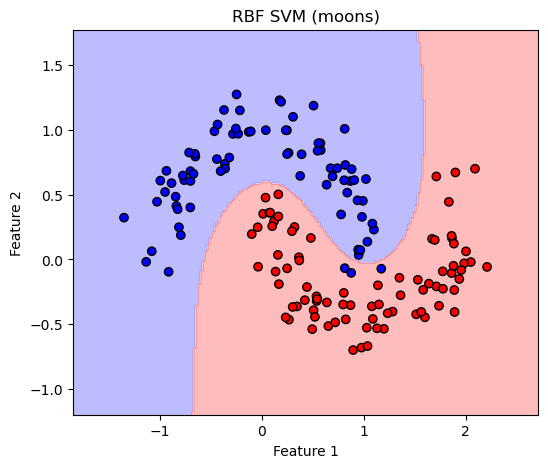

In [11]:
# TODO: Train an RBF kernel SVM on the moons data
clf_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
clf_rbf.fit(X_train_moon, y_train_moon)

y_pred_rbf = clf_rbf.predict(X_test_moon)
acc_rbf = accuracy_score(y_test_moon, y_pred_rbf)
print(f"RBF SVM accuracy on moons: {acc_rbf:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(clf_rbf, X_train_moon, y_train_moon, 'RBF SVM (moons)', ax)
plt.show()

In [13]:
print("="*50)
print(f"Linear SVM accuracy (linearly separable): {acc_lin:.4f}")
print(f"Linear SVM accuracy (moons): {acc_lin_moon:.4f}")
print(f"RBF SVM accuracy (moons): {acc_rbf:.4f}")
print("="*50)

Linear SVM accuracy (linearly separable): 0.9000
Linear SVM accuracy (moons): 0.8500
RBF SVM accuracy (moons): 0.9750


In [15]:
results = []
for C in Cs:
    for gamma in gammas:
        clf = SVC(kernel='rbf', C=C, gamma=gamma)
        clf.fit(X_train_moon, y_train_moon)
        acc = accuracy_score(y_test_moon, clf.predict(X_test_moon))
        results.append((C, gamma, acc))
        print(f"C={C}, gamma={gamma} -> accuracy: {acc:.4f}")

# Find best combination
best = max(results, key=lambda x: x[2])
print(f"\nBest: C={best[0]}, gamma={best[1]} -> accuracy: {best[2]:.4f}")

NameError: name 'Cs' is not defined

## Questions to Answer

1. **Why did linear SVM work perfectly on the first dataset but fail on the moons?**  
   (Hint: think about the shape of the decision boundary.)

2. **What does the RBF kernel do to the feature space?** How does it help separate the moons?

3. **In the RBF SVM, what is the effect of increasing `C`?** What about increasing `gamma`?  
   (Refer to your experiments in Cell 8.)

4. **If you increase `gamma` too much, what happens?** (Look at the decision boundary – does it become too wiggly?)

5. **How would you choose the best `C` and `gamma` for a real problem?** (Hint: mention cross‑validation.)

Write your answers below.